C:\Users\mdmah\AppData\Local\Temp\ipykernel_30444\1797379856.py:9: UnicodeWarning: 
One or more strings in the dta file could not be decoded using utf-8, and
so the fallback encoding of latin-1 is being used.  This can happen when a file
has been incorrectly encoded by Stata or some other software. You should verify
the string values returned are correct.
  df = pd.read_stata("../data/data.dta")


Longitudinal sample shape: (1605, 20)

Group counts:
group
Straight    1356
LGB          239
Name: count, dtype: int64

Weight summary:
count    1162.000000
mean        0.904991
std         0.888812
min         0.026903
25%         0.437855
50%         0.678715
75%         1.055606
max        10.109859
Name: w3_attrition_adj_weight, dtype: float64

Summary preview:
       Group  Year     Metric     Value        Type
0   Straight  2017        q_w  4.567673  Unweighted
1   Straight  2017        q_w  4.521249    Weighted
2   Straight  2020        q_w  4.474197  Unweighted
3   Straight  2020        q_w  4.444504    Weighted
4   Straight  2022        q_w  4.423564  Unweighted
5   Straight  2022        q_w  4.394061    Weighted
6   Straight  2017    sex_val  5.090631  Unweighted
7   Straight  2017    sex_val  6.294448    Weighted
8   Straight  2020    sex_val  4.377847  Unweighted
9   Straight  2020    sex_val  5.602623    Weighted
10  Straight  2022    sex_val  4.110302  Unweighted
11  Stra

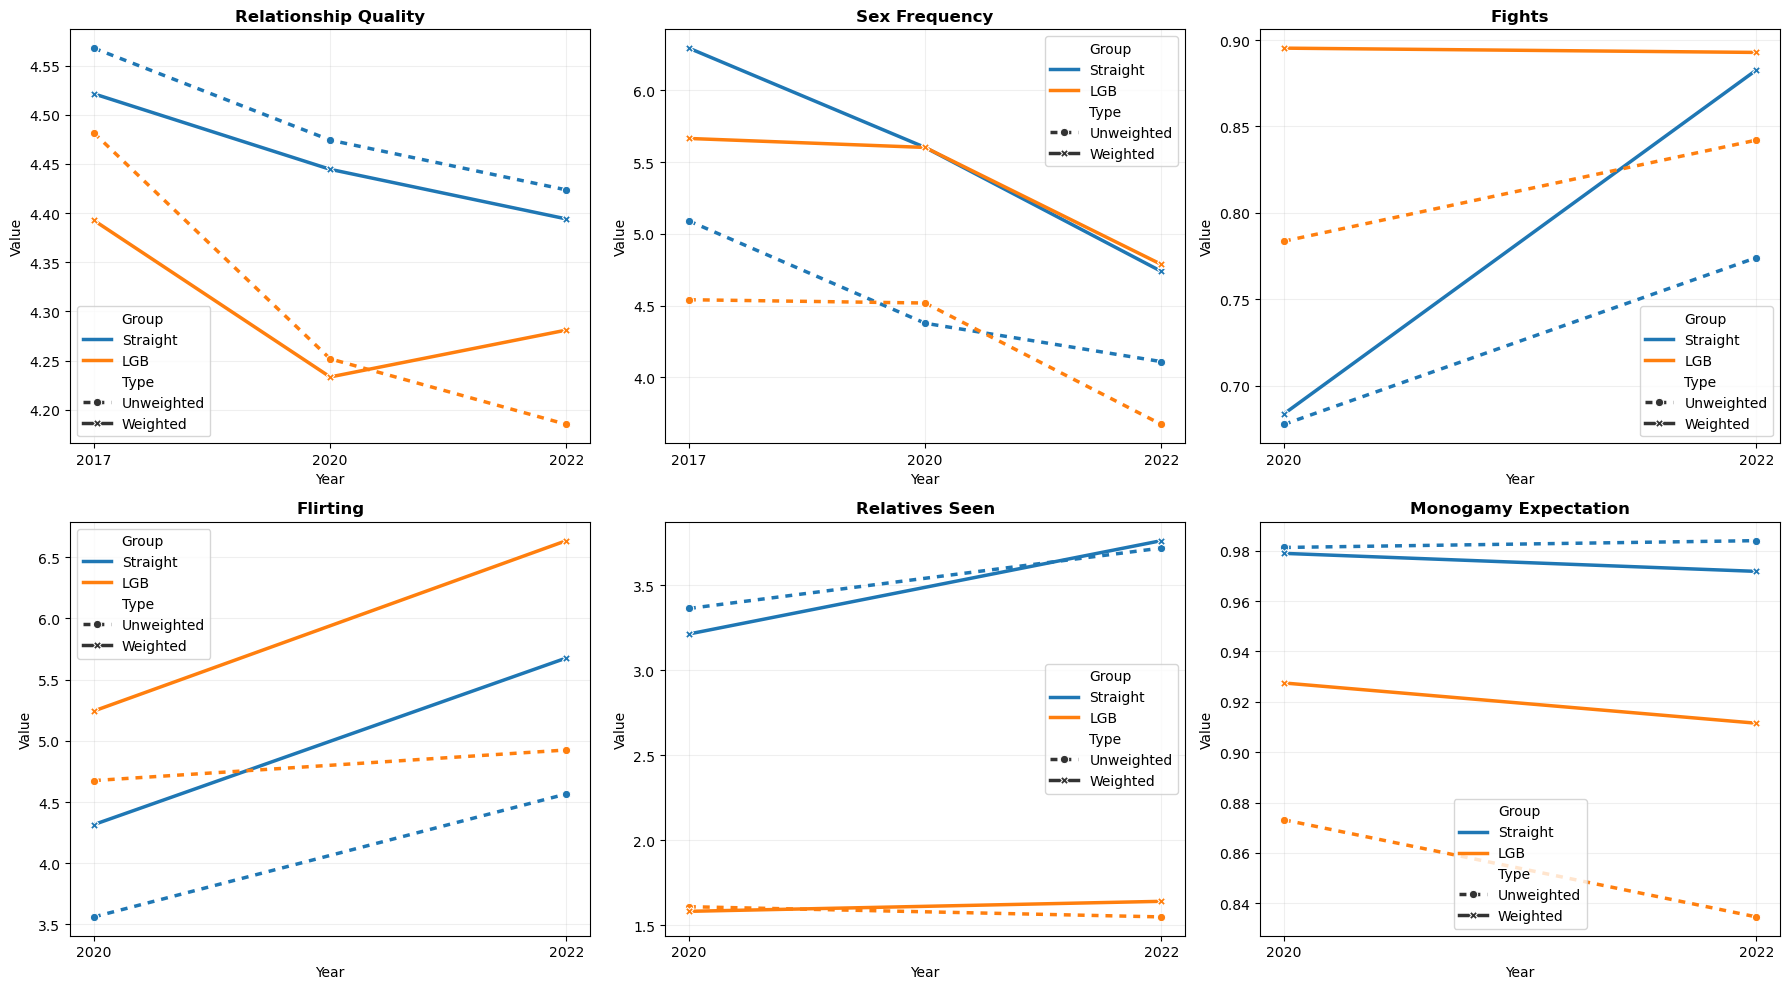

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1. LOAD DATA
# =========================
df = pd.read_stata("../data/data.dta")

# =========================
# 2. SELECT COLUMNS
# =========================
cols = [
    "caseid_new",

    # identity / grouping
    "w1_identity_all_modified",

    # surveyed flags
    "w2_surveyed",
    "w3_surveyed",

    # weights
    "w3_attrition_adj_weight",

    # relationship quality
    "w1_q34",
    "w2_rel_qual_combo",
    "w3_rel_qual",

    # sex frequency
    "w1_sex_frequency",
    "w2_sex_frequency",
    "w3_sex_frequency",

    # fights
    "w2_fight",
    "w3_fight",

    # flirting
    "w2_flirt",
    "w3_flirt",

    # relatives
    "w2_relatives",
    "w3_relatives",

    # monogamy
    "w2_p_monogamy",
    "w3_p_monogamy",

    # optional contextual variable if you want later analysis
    "w2_coronavirus_effect_combo"
]

df_time = df[cols].copy()

# =========================
# 3. KEEP LONGITUDINAL SAMPLE
# =========================
df_time = df_time[
    (df_time["w2_surveyed"] == "yes") &
    (df_time["w3_surveyed"] == "yes")
].copy()

print("Longitudinal sample shape:", df_time.shape)

# =========================
# 4. CLASSIFY ORIENTATION
# =========================
def classify_orientation(x):
    if pd.isna(x):
        return np.nan
    x = str(x).lower()
    if any(i in x for i in ["gay", "lesbian", "bisexual"]):
        return "LGB"
    elif "straight" in x or "hetero" in x:
        return "Straight"
    else:
        return np.nan

df_time["group"] = df_time["w1_identity_all_modified"].apply(classify_orientation)
df_time = df_time.dropna(subset=["group"]).copy()

print("\nGroup counts:")
print(df_time["group"].value_counts(dropna=False))

# =========================
# 5. MAP RELATIONSHIP QUALITY
# =========================
quality_map = {
    "Excellent": 5,
    "Good": 4,
    "Fair": 3,
    "Poor": 2,
    "Very Poor": 1
}

df_time["q_w1"] = df_time["w1_q34"].map(quality_map)
df_time["q_w2"] = df_time["w2_rel_qual_combo"].map(quality_map)
df_time["q_w3"] = df_time["w3_rel_qual"].map(quality_map)

df_time = df_time.dropna(subset=["q_w1", "q_w2", "q_w3"]).copy()

df_time = df_time.dropna(subset=["q_w1", "q_w2", "q_w3"]).copy()

for col in ["q_w1", "q_w2", "q_w3"]:
    df_time[col] = pd.to_numeric(df_time[col], errors="coerce")

# =========================
# 6. MAP BEHAVIOR VARIABLES
# =========================

# Sex frequency
sex_map = {
    "Once a month or less": 1.0,
    "2 to 3 times a month": 2.5,
    "Once or twice a week": 6.0,
    "3 to 6 times a week": 18.0,
    "Once a day or more": 30.0,
    "Refused": np.nan
}

# Flirting
flirt_map = {
    "Never": 0.0,
    "Less than once a month": 0.5,
    "1-3 times a month": 2.0,
    "Once a week": 4.0,
    "A few times a week": 12.0,
    "Every day": 30.0
}

# Fighting
fight_map = {
    "0 times (no arguments or fights)": 0.0,
    "we argued or fought once": 1.0,
    "we argued or fought twice": 2.0,
    "we argued or fought 3 times": 3.0,
    "we argued or fought 4 times": 4.0,
    "we argued or fought 5 times": 5.0,
    "we argued or fought 6 times": 6.0,
    "we argued or fought 7 times or more": 7.0
}

# Monogamy
monog_map = {
    "Yes, I expect that [xnamep] will only have sex with me": 1.0,
    "yes, I expect partner will only have sex with me": 1.0,
    "No, I expect [xnamep] to have sex with other people besides me": 0.0,
    "No, i expect partner to have sex with others": 0.0
}

# Apply maps
df_time["sex_val_w1"] = df_time["w1_sex_frequency"].map(sex_map)
df_time["sex_val_w2"] = df_time["w2_sex_frequency"].map(sex_map)
df_time["sex_val_w3"] = df_time["w3_sex_frequency"].map(sex_map)

df_time["fight_val_w2"] = df_time["w2_fight"].map(fight_map)
df_time["fight_val_w3"] = df_time["w3_fight"].map(fight_map)

df_time["flirt_val_w2"] = df_time["w2_flirt"].map(flirt_map)
df_time["flirt_val_w3"] = df_time["w3_flirt"].map(flirt_map)

df_time["rel_val_w2"] = pd.to_numeric(df_time["w2_relatives"], errors="coerce")
df_time["rel_val_w3"] = pd.to_numeric(df_time["w3_relatives"], errors="coerce")

df_time["monog_val_w2"] = df_time["w2_p_monogamy"].map(monog_map)
df_time["monog_val_w3"] = df_time["w3_p_monogamy"].map(monog_map)

# =========================
# 7. CLEAN NUMERIC COLUMNS
# =========================
numeric_cols = [
    "w3_attrition_adj_weight",
    "q_w1", "q_w2", "q_w3",
    "sex_val_w1", "sex_val_w2", "sex_val_w3",
    "fight_val_w2", "fight_val_w3",
    "flirt_val_w2", "flirt_val_w3",
    "rel_val_w2", "rel_val_w3",
    "monog_val_w2", "monog_val_w3"
]

for col in numeric_cols:
    df_time[col] = pd.to_numeric(df_time[col], errors="coerce")

# keep valid weights
df_time = df_time.dropna(subset=["w3_attrition_adj_weight"]).copy()
df_time = df_time[df_time["w3_attrition_adj_weight"] > 0].copy()

print("\nWeight summary:")
print(df_time["w3_attrition_adj_weight"].describe())

# =========================
# 8. WEIGHTED MEAN HELPER
# =========================
def weighted_mean(x, w):
    x = pd.to_numeric(x, errors="coerce")
    w = pd.to_numeric(w, errors="coerce")
    mask = x.notna() & w.notna() & (w > 0)
    x = x[mask]
    w = w[mask]
    return np.average(x, weights=w) if len(x) > 0 else np.nan

# =========================
# 9. BUILD SUMMARY TABLE
# =========================
plot_rows = []

metric_map = {
    "q_w": ["q_w1", "q_w2", "q_w3"],
    "sex_val": ["sex_val_w1", "sex_val_w2", "sex_val_w3"],
    "fight_val": [None, "fight_val_w2", "fight_val_w3"],
    "flirt_val": [None, "flirt_val_w2", "flirt_val_w3"],
    "rel_val": [None, "rel_val_w2", "rel_val_w3"],
    "monog_val": [None, "monog_val_w2", "monog_val_w3"]
}

years = ["2017", "2020", "2022"]

for group_name in ["Straight", "LGB"]:
    g = df_time[df_time["group"] == group_name]

    for metric, cols_3 in metric_map.items():
        for year, col in zip(years, cols_3):
            if col is None or col not in g.columns:
                continue

            raw_val = pd.to_numeric(g[col], errors="coerce").mean()
            adj_val = weighted_mean(g[col], g["w3_attrition_adj_weight"])

            plot_rows.append({
                "Group": group_name,
                "Year": year,
                "Metric": metric,
                "Value": raw_val,
                "Type": "Unweighted"
            })

            plot_rows.append({
                "Group": group_name,
                "Year": year,
                "Metric": metric,
                "Value": adj_val,
                "Type": "Weighted"
            })

summary_all = pd.DataFrame(plot_rows)

print("\nSummary preview:")
print(summary_all)

# =========================
# 10. OPTIONAL: SEE TABLES BY METRIC
# =========================
for metric in ["q_w", "sex_val", "fight_val", "flirt_val", "rel_val", "monog_val"]:
    print(f"\n=== {metric} ===")
    print(
        summary_all[summary_all["Metric"] == metric]
        .pivot_table(index=["Group", "Type"], columns="Year", values="Value")
    )

# =========================
# 11. PLOT ALL METRICS
# =========================
titles = {
    "q_w": "Relationship Quality",
    "sex_val": "Sex Frequency",
    "fight_val": "Fights",
    "flirt_val": "Flirting",
    "rel_val": "Relatives Seen",
    "monog_val": "Monogamy Expectation"
}

metric_order = ["q_w", "sex_val", "fight_val", "flirt_val", "rel_val", "monog_val"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, metric in enumerate(metric_order):
    subset = summary_all[summary_all["Metric"] == metric]

    sns.lineplot(
        ax=axes[i],
        data=subset,
        x="Year",
        y="Value",
        hue="Group",
        style="Type",
        markers=True,
        dashes={"Unweighted": (2, 2), "Weighted": ""},
        linewidth=2.5
    )

    axes[i].set_title(titles[metric], fontweight="bold")
    axes[i].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()